# Prompt 4B4 - Imbalance-Aware Global Training

Prompt 4B3 ended the adaptive routing line. Prompt 4B4 changes Global training instead. All results below are adaptive Development evidence.

In [1]:
from pathlib import Path
import json, pandas as pd
from IPython.display import display, Image
ROOT=Path.cwd().resolve(); ROOT=ROOT if (ROOT/'outputs').exists() else ROOT.parent
REPORTS=ROOT/'outputs/reports'; FIGURES=ROOT/'outputs/figures/prompt4b4'

## Frozen design and literature methods

DenseWeight and LDS use Train-only sample weights. SERA uses Train-only relevance. IMr-GB uses a Train-only label prior. None is an inference feature. The budget is exactly four scientific fits.

In [2]:
design=json.loads((REPORTS/'prompt4b4_design_freeze.json').read_text()); reproduction=json.loads((REPORTS/'prompt4b4_method_reproduction.json').read_text()); display(pd.DataFrame(reproduction['methods']).T); display(pd.DataFrame([design['fit_budget']]))

,status,paper_title,year,identifier,official_source,source_commit,package_version,formula,configuration,synthetic_max_difference,project_adaptation,synthetic_derivative_coefficient_max_difference,variant,synthetic_gradient_max_difference_vs_official_torch_equation,synthetic_hessian_max_difference,bayes_path_disposition,source_disclosure,synthetic_positive_mean_one
DenseWeight,PASS,Density-based weighting for imbalanced regression,2021,10.1007/s10994-021-06023-5,SteiMi/denseweight,dd61852123a0e243b0393eaa7c077c71ed593dfd,0.1.2,FFTKDE Silverman bandwidth; min-max density; m...,"{'alpha': 1.0, 'grid_points': 4096, 'eps': 1e-06}",0.0,Official package output used directly as CatBo...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SERA,PASS,Model Optimization in Imbalanced Regression,2022,arXiv:2206.09991,anibalsilva1/ModelOptimizationIR,decacae4432aeb2c08d803f94d48c3de5ddddf68,NaN,sigma(phi)=trapezoidal integral of 1[phi>=t]; ...,"{'extreme_type': 'high', 'adjusted_boxplot': T...",NaN,IRon 0.1.5 computes Train-only relevance; Pyth...,0.0,NaN,NaN,NaN,NaN,NaN,NaN
IMr-GB,PASS,A novel gradient boosting approach for imbalan...,2024,10.1016/j.neucom.2024.128091,vengozhang/IMr-GB,128e652e7eadedbbb658b96b89f23bdbb21b223e,NaN,tutorial Balanced-MSE gradient with smoothed G...,"{'n_components': 6, 'noise_var': 1.0, 'random_...",NaN,NaN,NaN,standard IMr-GB fixed six-component GMM,0.0,0.0,Authors' tutorial fixes BGM upper bound to 10%...,Root IMb_MSE.py has a loss-sign inconsistency;...,NaN
LDS,PASS,Delving into Deep Imbalanced Regression,2021,PMLR 139; arXiv:2102.09554,YyzHarry/imbalanced-regression,a6fdc45d45c04e6f5c40f43925bc66e580911084,NaN,sqrt empirical frequency; convolve with max-no...,"{'bin_width': 1.0, 'reweight': 'sqrt_inv', 'ke...",NaN,Natural thousand-dollar target bins and LightG...,NaN,NaN,NaN,NaN,NaN,NaN,True


,intended,maximum,max_identical_technical_retry_per_candidate,heavy_fits_sequential
0,4,4,1,True


## Training diagnostics

These figures explain how target imbalance changes training loss only.

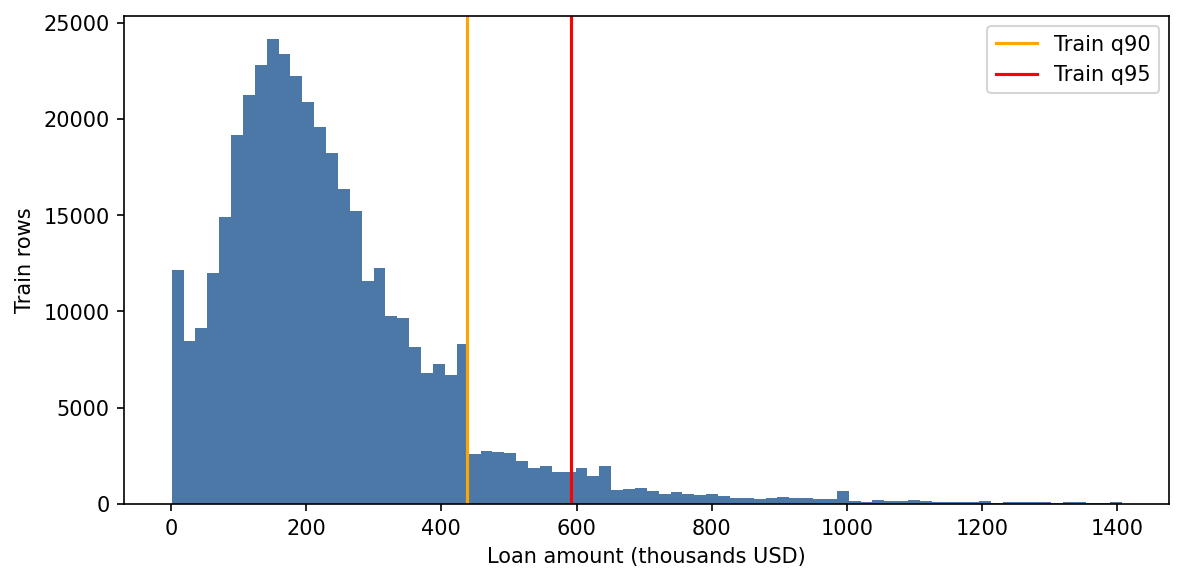

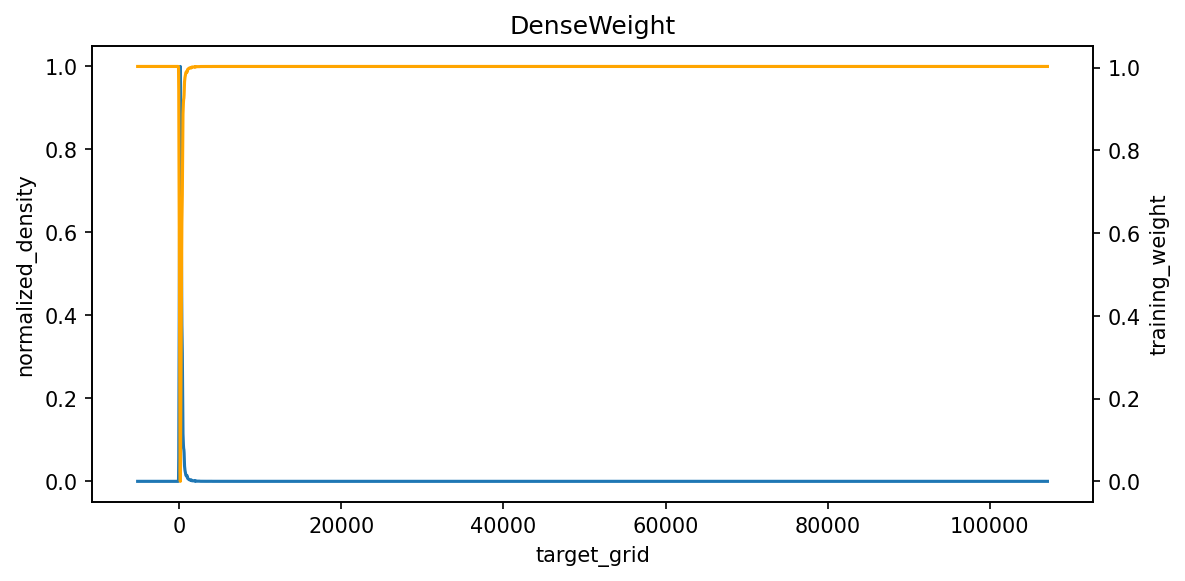

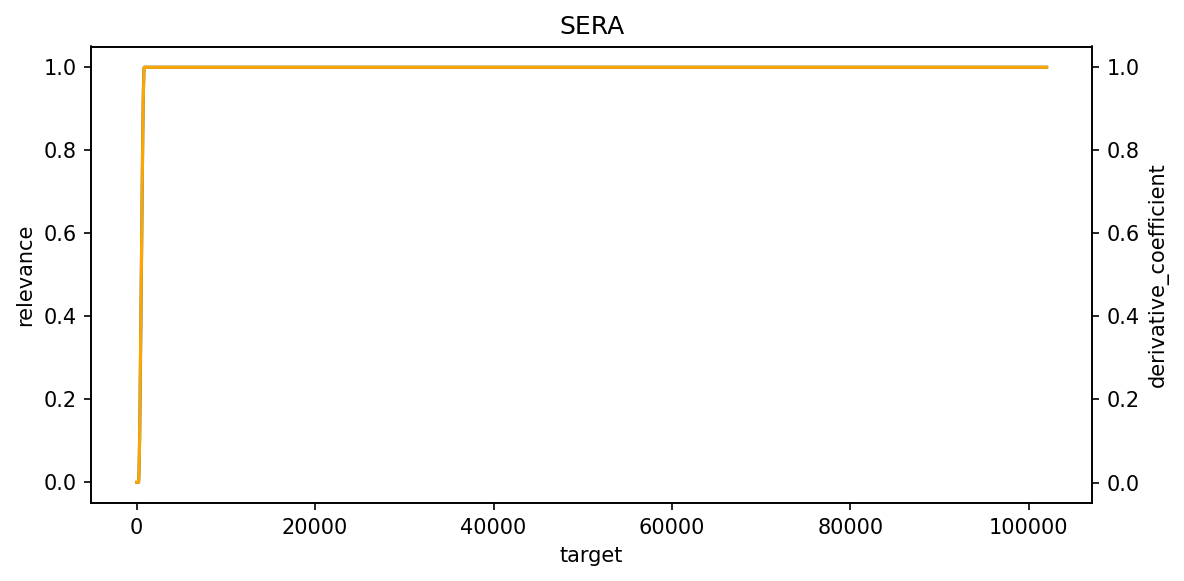

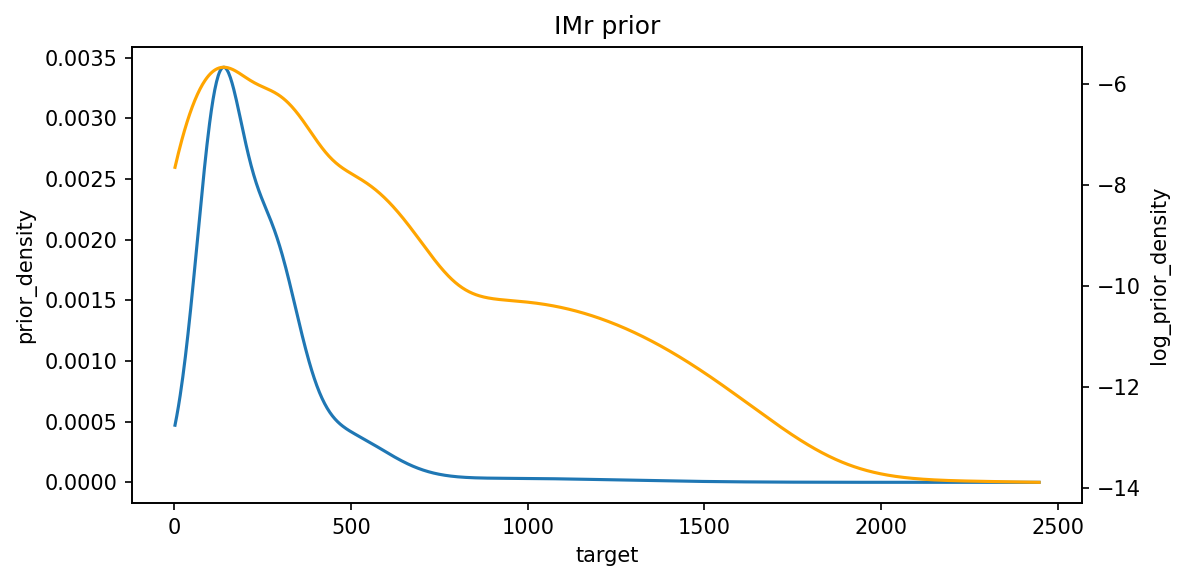

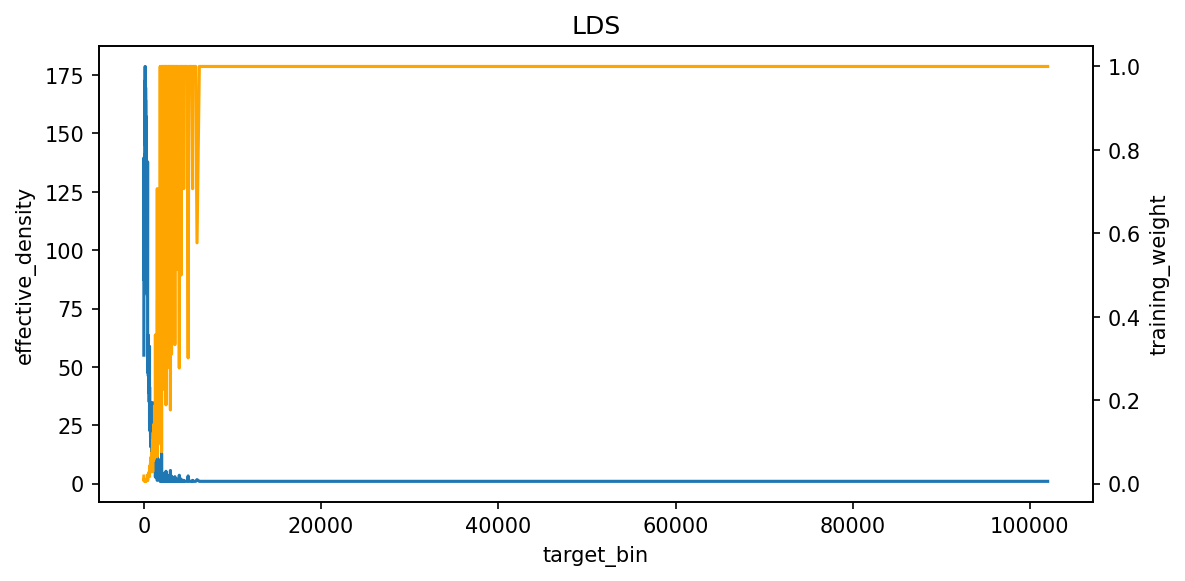

In [3]:
for name in ['01_train_target_distribution.png','02_denseweight.png','03_sera.png','04_imr_prior.png','05_lds.png']: display(Image(filename=str(FIGURES/name)))

## Standalone and fixed substitutions

The four substitutions reuse the original 0.60/0.20/0.20 Global weights. No ensemble weight was searched.

In [4]:
display(pd.read_csv(REPORTS/'prompt4b4_candidate_results.csv')); display(pd.read_csv(REPORTS/'prompt4b4_six_condition_results.csv'))

,candidate_id,candidate_kind,scope,evidence_label,complexity,n_rows,mae,rmse,r2,rmsle,...,top_decile_mae,top_five_percent_mae,top_decile_signed_error,top_five_percent_signed_error,top_decile_underprediction_rate,top_five_percent_underprediction_rate,p85_to_p95_boundary_mae,top_decile_rows,top_five_percent_rows,boundary_rows
0,prompt4b4__denseweight_cat,standalone,selection,adaptive Development evidence,2,70000,63.039096,128.743593,0.687517,0.396855,...,196.356151,283.309376,-136.874455,-215.975695,0.789504,0.820097,97.922978,7012,3513,7040
1,prompt4b4__denseweight_cat,standalone,audit_descriptive,adaptive Development evidence,2,30000,62.572352,121.107966,0.696232,0.395778,...,189.561968,268.648068,-133.739354,-208.234695,0.784072,0.813953,99.113906,3001,1505,3009
2,prompt4b4__denseweight_cat,standalone,complete_validation_descriptive,adaptive Development evidence,2,100000,62.899073,126.501307,0.689964,0.396532,...,194.319863,278.904538,-135.934833,-213.751619,0.787876,0.818617,98.182411,10013,5017,10038
3,prompt4b4__sera_xgb,standalone,selection,adaptive Development evidence,2,70000,111.831478,178.344421,0.400355,0.867447,...,293.429437,419.370858,-276.381284,-402.176173,0.949230,0.964703,141.738992,7012,3513,7040
4,prompt4b4__sera_xgb,standalone,audit_descriptive,adaptive Development evidence,2,30000,111.424429,171.500027,0.390849,0.868377,...,287.937468,406.806063,-272.389680,-390.534338,0.954682,0.970764,143.601691,3001,1505,3009
5,prompt4b4__sera_xgb,standalone,complete_validation_descriptive,adaptive Development evidence,2,100000,111.709363,176.319002,0.397690,0.867726,...,291.783437,415.603626,-275.184959,-398.682383,0.950864,0.966514,142.222892,10013,5017,10038
6,prompt4b4__imrgb,standalone,selection,adaptive Development evidence,2,70000,66.143471,151.378090,0.567982,0.488452,...,198.691396,283.592427,-95.192006,-147.153227,0.752282,0.769143,102.014676,7012,3513,7040
7,prompt4b4__imrgb,standalone,audit_descriptive,adaptive Development evidence,2,30000,65.499686,133.143391,0.632857,0.489168,...,188.715060,263.056017,-101.045934,-153.467449,0.754415,0.773422,104.556451,3001,1505,3009
8,prompt4b4__imrgb,standalone,complete_validation_descriptive,adaptive Development evidence,2,100000,65.950336,146.146765,0.586191,0.488667,...,195.701385,277.433238,-96.946489,-149.064273,0.752921,0.770580,102.722259,10013,5017,10038
9,prompt4b4__lds_lgb,standalone,selection,adaptive Development evidence,2,70000,75.254740,152.632790,0.560791,0.507774,...,199.235595,265.701548,13.428972,3.795408,0.565602,0.577569,122.657114,7012,3513,7040


,candidate_id,scope,C1_overall_mae_improves,C2_top_decile_mae_improves_3pct,C3_bottom_90_mae_worsens_at_most_0_25pct,C4_rmse_worsens_at_most_0_25pct,C5_top_decile_signed_error_closer_to_zero,C6_top_decile_underprediction_rate_decreases,conditions_passed,conditions_total,status
0,prompt4b4__denseweight_cat,selection,False,False,False,False,True,True,2,6,PARTIAL
1,prompt4b4__denseweight_cat,audit_descriptive,False,False,False,False,True,True,2,6,PARTIAL
2,prompt4b4__denseweight_cat,complete_validation_descriptive,False,False,False,False,True,True,2,6,PARTIAL
3,prompt4b4__sera_xgb,selection,False,False,False,False,False,False,0,6,FAIL
4,prompt4b4__sera_xgb,audit_descriptive,False,False,False,False,False,False,0,6,FAIL
5,prompt4b4__sera_xgb,complete_validation_descriptive,False,False,False,False,False,False,0,6,FAIL
6,prompt4b4__imrgb,selection,False,False,False,False,True,True,2,6,PARTIAL
7,prompt4b4__imrgb,audit_descriptive,False,False,False,False,True,True,2,6,PARTIAL
8,prompt4b4__imrgb,complete_validation_descriptive,False,False,False,False,True,True,2,6,PARTIAL
9,prompt4b4__lds_lgb,selection,False,False,False,False,True,True,2,6,PARTIAL


## Body/Tail evidence and frozen roles

Selection alone froze the Tail-aware champion and MAE challenger. Audit and complete Validation did not change them.

,status,created_at_utc,selection_only,tailaware_champion,mae_challenger,roles_may_match,final_project_model,final_project_model_frozen,complete_validation_descriptive,TAIL_RUBRIC_BREAKTHROUGH,NEW_DEVELOPMENT_MAE_RECORD
0,PASS,2026-08-07T12:11:58.623813+00:00,True,prompt4b4__sub_ldslgb,prompt4b4__sub_densecat,True,False,False,{'prompt4b4__sub_densecat': {'candidate_id': '...,False,False


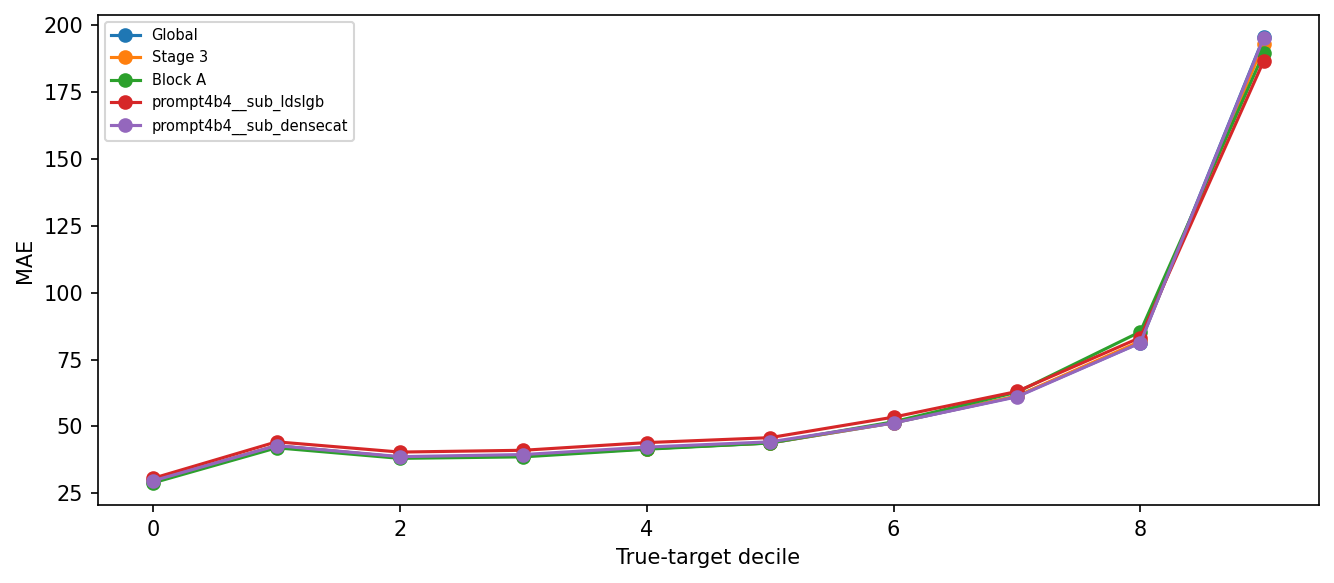

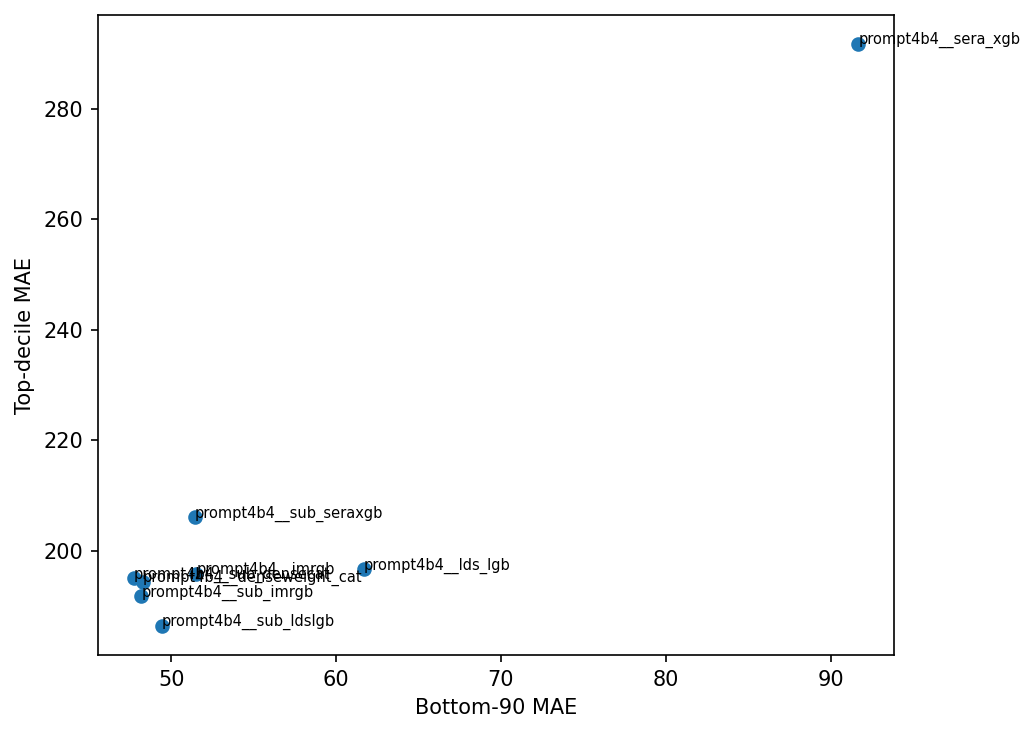

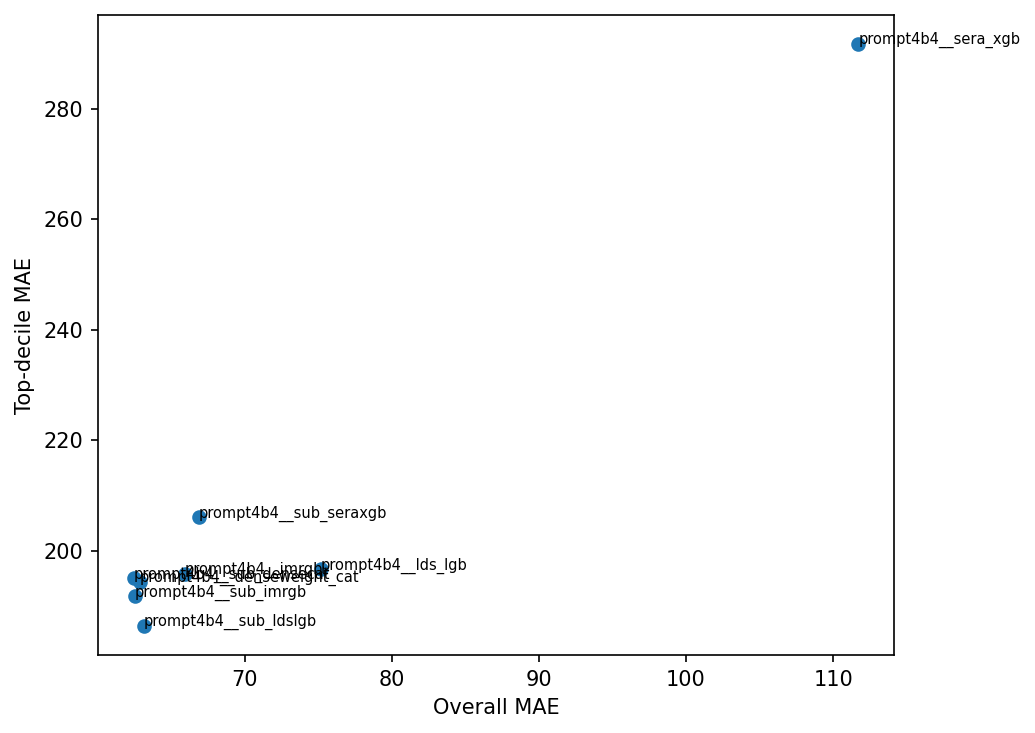

In [5]:
roles=json.loads((REPORTS/'prompt4b4_champion_selection.json').read_text()); display(pd.DataFrame([roles])); display(Image(filename=str(FIGURES/'06_validation_decile_mae.png'))); display(Image(filename=str(FIGURES/'07_body_tail_pareto.png'))); display(Image(filename=str(FIGURES/'08_mae_vs_top_decile.png')))

## Descriptive uncertainty and closure

The paired bootstrap is adaptive Development evidence, not independent confirmation. IID remains unopened. No final project model is selected or frozen, and Prompt 4C was not executed.

In [6]:
display(pd.read_csv(REPORTS/'prompt4b4_bootstrap.csv')); display(pd.read_csv(REPORTS/'prompt4b4_cross_stage_comparison.csv'))

,candidate_id,reference_id,metric,mean_difference,median_difference,percentile_2_5,percentile_97_5,probability_difference_lt_zero,resamples,seed,label
0,prompt4b4__sub_ldslgb,ens_boost_cat060,overall_mae,0.778692,0.780442,0.651422,0.900638,0.00,500,42,adaptive Development descriptive bootstrap
1,prompt4b4__sub_ldslgb,ens_boost_cat060,bottom_90_mae,1.849718,1.846960,1.775684,1.925834,0.00,500,42,adaptive Development descriptive bootstrap
2,prompt4b4__sub_ldslgb,ens_boost_cat060,top_decile_mae,-8.845558,-8.839393,-9.854550,-7.830597,1.00,500,42,adaptive Development descriptive bootstrap
3,prompt4b4__sub_ldslgb,stage3_residual_t75_a75,overall_mae,0.938893,0.938332,0.838557,1.041702,0.00,500,42,adaptive Development descriptive bootstrap
4,prompt4b4__sub_ldslgb,stage3_residual_t75_a75,bottom_90_mae,1.757631,1.755376,1.685620,1.831951,0.00,500,42,adaptive Development descriptive bootstrap
5,prompt4b4__sub_ldslgb,stage3_residual_t75_a75,top_decile_mae,-6.418215,-6.417605,-7.200148,-5.653304,1.00,500,42,adaptive Development descriptive bootstrap
6,prompt4b4__sub_ldslgb,nf_global2_oldraw_direct_cap25,overall_mae,1.021206,1.022289,0.905436,1.131958,0.00,500,42,adaptive Development descriptive bootstrap
7,prompt4b4__sub_ldslgb,nf_global2_oldraw_direct_cap25,bottom_90_mae,1.457027,1.455353,1.380650,1.536315,0.00,500,42,adaptive Development descriptive bootstrap
8,prompt4b4__sub_ldslgb,nf_global2_oldraw_direct_cap25,top_decile_mae,-2.894880,-2.876940,-3.933590,-1.969020,1.00,500,42,adaptive Development descriptive bootstrap
9,prompt4b4__sub_densecat,ens_boost_cat060,overall_mae,0.126259,0.125235,0.085023,0.169023,0.00,500,42,adaptive Development descriptive bootstrap


,candidate_id,candidate_kind,scope,evidence_label,complexity,n_rows,mae,rmse,r2,rmsle,...,top_decile_signed_error,top_five_percent_signed_error,top_decile_underprediction_rate,top_five_percent_underprediction_rate,p85_to_p95_boundary_mae,top_decile_rows,top_five_percent_rows,boundary_rows,tailaware_champion,mae_challenger
0,ens_boost_cat060,prior_reference,selection,adaptive Development evidence,3,70000,62.519519,127.522273,0.693417,0.390892,...,-139.967780,-219.644799,0.795779,0.823513,98.754646,7012,3513,7040,False,False
1,ens_boost_cat060,prior_reference,audit_descriptive,adaptive Development evidence,3,30000,61.975508,120.365860,0.699944,0.390676,...,-136.919968,-211.772167,0.789737,0.819934,99.716455,3001,1505,3009,False,False
2,ens_boost_cat060,prior_reference,complete_validation_descriptive,adaptive Development evidence,3,100000,62.356316,125.418232,0.695250,0.390827,...,-139.054319,-217.348658,0.793968,0.822603,98.963799,10013,5017,10038,False,False
3,stage3_residual_t75_a75,prior_reference,selection,adaptive Development evidence,3,70000,62.352823,124.927516,0.705767,0.390820,...,-128.026097,-198.283977,0.777809,0.794478,100.055070,7012,3513,7040,False,False
4,stage3_residual_t75_a75,prior_reference,audit_descriptive,adaptive Development evidence,3,30000,61.832268,118.513757,0.709107,0.390574,...,-125.721796,-192.064247,0.776075,0.798007,101.262785,3001,1505,3009,False,False
5,stage3_residual_t75_a75,prior_reference,complete_validation_descriptive,adaptive Development evidence,3,100000,62.196656,123.038499,0.706706,0.390746,...,-127.335474,-196.495980,0.777290,0.795894,100.338601,10013,5017,10038,False,False
6,nf_global2_oldraw_direct_cap25,prior_reference,selection,adaptive Development evidence,3,70000,62.249933,126.516126,0.698236,0.386333,...,-126.628966,-201.325281,0.764546,0.804441,101.425043,7012,3513,7040,False,False
7,nf_global2_oldraw_direct_cap25,prior_reference,audit_descriptive,adaptive Development evidence,3,30000,61.799286,119.434236,0.704570,0.385849,...,-123.876242,-194.460512,0.755082,0.802658,103.260310,3001,1505,3009,False,False
8,nf_global2_oldraw_direct_cap25,prior_reference,complete_validation_descriptive,adaptive Development evidence,3,100000,62.114739,124.433887,0.700015,0.386188,...,-125.803946,-199.337733,0.761710,0.804066,101.912247,10013,5017,10038,False,False
9,prompt4b3__beat_costaware,prior_reference,selection,adaptive Development evidence,3,70000,62.501388,127.419488,0.693911,0.390853,...,-139.566809,-218.934171,0.795066,0.822659,98.756214,7012,3513,7040,False,False
